In [1]:
import scanpy as sc
import muon as mu
import omics_topic as ot
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings('ignore', message='.*was not registered in the param store.*')
warnings.filterwarnings('ignore', message='.*Found plate statements in guide but not model.*')

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ATAC lymphoma dataset

mdata = mu.read_h5mu("/data/nelkazwi/share-topic/lymphoma_data/mdata_lymphoma.h5mu")

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [3]:
mdata

MuData object with n_obs × n_vars = 14566 × 33907
  var:	'n_cells'
  uns:	'mofa', 'neighbors', 'umap'
  obsm:	'X_mofa', 'X_umap'
  varm:	'LFs'
  obsp:	'connectivities', 'distances'
  2 modalities
    atac:	14566 x 25812
      obs:	'cell_types'
      var:	'n_cells'
    rna:	14566 x 8095
      obs:	'cell_types'
      var:	'gene_ids', 'feature_types', 'n_cells'

In [5]:
import mudata as md
from omics_topic.models import MultimodalAmortizedLDA

# Create model directly from MuData with automatic extraction
model = MultimodalAmortizedLDA.from_data(
    mdata,
    modalities=["rna", "atac"],  # specify which modalities to use
    #layers={"rna": "counts", "atac": "counts"},  # or layers="counts" for all
    n_topics=10,
    likelihoods=["gamma_poisson", "multinomial"],  # one per modality
    n_hidden=64,
    cell_topic_prior=1/10
)

In [6]:
print("spatial flag:", model.spatial)                             
print("use_gcn:", model.module.guide.use_gcn)                     
print("gcn encoders:", model.module.guide.gcn_encoders is not None)

spatial flag: False
use_gcn: False
gcn encoders: False


In [ ]:
# I only do 400 cause the data is very high dimensional, about 20 mins on A40

model.train(
    max_epochs=200,
    batch_size=128,  
    train_size=0.8,          
    validation_size=0.2,      
    log_every_n_steps=1,     
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 201/400:  50%|█████     | 200/400 [11:24<10:44,  3.22s/it, v_num=1, elbo_val=2.27e+8, elbo_train=8.83e+8]


Detected KeyboardInterrupt, attempting graceful shutdown ...


Text(0, 0.5, 'ELBO')

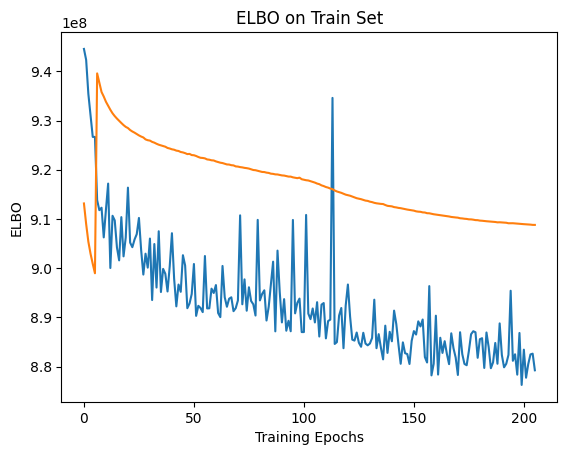

In [9]:
plt.plot(model.history['elbo_train'])
plt.plot(model.history['elbo_val']*4)
plt.title('ELBO on Train Set')
plt.xlabel('Training Epochs')
plt.ylabel('ELBO')

In [10]:
#This API is terrible, I really need to change it

adata_concat = mdata.uns["_flattened_ann_data"]

# Get latent representation
theta = model.get_latent_representation(adata_concat, batch_size=mdata.n_obs)

In [11]:
mdata.obsm["X_topic"] = theta.values - 1/theta.values.shape[1]

sc.pp.neighbors(mdata, use_rep="X_topic", n_neighbors=15, metric="cosine")
sc.tl.umap(mdata, min_dist=0.3)

# 3) Get dominant topic per cell
mdata.obs["dominant_topic"] = theta.idxmax(axis=1).values

# 4) IMPORTANT: Clean up any old color information to avoid conflicts
if "dominant_topic_colors" in mdata.uns:
    del mdata.uns["dominant_topic_colors"]

# 5) Convert to categorical for better plotting
mdata.obs["dominant_topic"] = pd.Categorical(mdata.obs["dominant_topic"])

Epoch 7/100:   6%|▌         | 6/100 [12:37<3:17:39, 126.17s/it, v_num=1, elbo_val=2.25e+8, elbo_train=9.27e+8]


In [18]:
mdata

MuData object with n_obs × n_vars = 14566 × 33907
  obs:	'dominant_topic'
  var:	'n_cells'
  uns:	'mofa', 'neighbors', 'umap', '_multimodal_setup', '_flattened_ann_data'
  obsm:	'X_mofa', 'X_umap', 'X_topic'
  varm:	'LFs'
  obsp:	'connectivities', 'distances'
  2 modalities
    atac:	14566 x 25812
      obs:	'cell_types'
      var:	'n_cells'
    rna:	14566 x 8095
      obs:	'cell_types'
      var:	'gene_ids', 'feature_types', 'n_cells'

In [20]:
mdata.obs['cell_type']=mdata['rna'].obs['cell_types']

<Axes: title={'center': 'UMAP colored by Cell Type'}, xlabel='X_umap1', ylabel='X_umap2'>

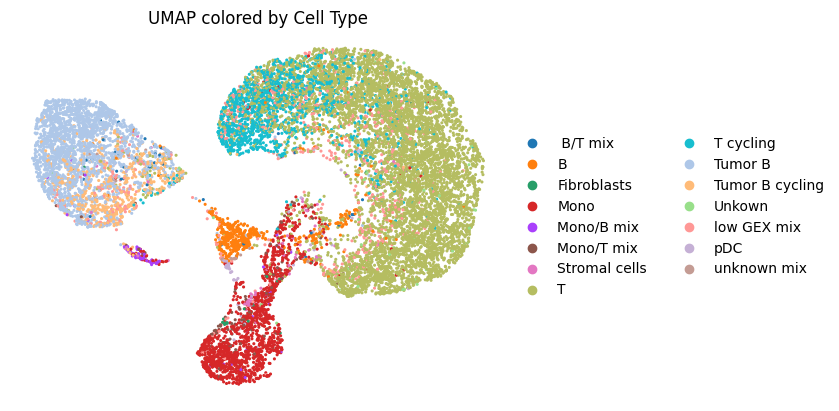

In [23]:
mu.pl.embedding(
    mdata,
    basis = "X_umap",
    color="cell_type",
    frameon=False,
    s=20,
    title="UMAP colored by Cell Type",
    show=False,
    legend_loc="right margin"
)

In [22]:
print("\n" + "="*70)
print("TOPIC ABUNDANCE SUMMARY")
print("="*70)

summary_df = pd.DataFrame({
    "Mean": theta.mean(),
    "Std": theta.std(),
    "Min": theta.min(),
    "Max": theta.max(),
    "# Dominant Spots": [(theta.idxmax(axis=1) == topic).sum() for topic in theta.columns]
})

print(summary_df.round(3).to_string())


TOPIC ABUNDANCE SUMMARY
          Mean    Std    Min    Max  # Dominant Spots
topic_0  0.054  0.080  0.000  0.408                54
topic_1  0.192  0.133  0.000  0.489              4461
topic_2  0.064  0.062  0.000  0.577               166
topic_3  0.056  0.084  0.000  0.472               216
topic_4  0.170  0.133  0.000  0.833              3009
topic_5  0.051  0.068  0.000  0.378                43
topic_6  0.158  0.093  0.001  0.521              2312
topic_7  0.059  0.094  0.000  0.527              1524
topic_8  0.132  0.059  0.000  0.373                25
topic_9  0.064  0.117  0.000  0.578              2756
